# 🎴 Exploratory Data Analysis (EDA) — Pokémon Card Value Analytic Tool

> **Proyek Analitika Data & Computer Vision Engine (PokeScan)**  
> **Dataset:** `pokemon_cards_dataset_cleaned.csv` (19.926 baris, 22 kolom fitur)  
> **Tujuan:** Menganalisis kualitas data, struktur kelangkaan (*rarity*), tren harga pasar (*effective market price*), faktor *vintage*, serta membuktikan kelayakan dataset untuk **Dual-Model Computer Vision** & **Valuation Engine ($P_{final}$)**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi Tema & Aesthetics Visualisasi
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

print("✅ Library berhasil dimuat & konfigurasi visualisasi aktif.")


✅ Library berhasil dimuat & konfigurasi visualisasi aktif.


In [2]:
# 1. Memuat Master Dataset Cleaned
csv_path = "../dataset/pokemon_cards_dataset_cleaned.csv"
df = pd.read_csv(csv_path)

# Memastikan format tanggal & numerik
df['set.release_date'] = pd.to_datetime(df['set.release_date'], errors='coerce')
df['release_year'] = df['release_year'].astype(int)

print(f"📊 Dimensi Dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head(3)


📊 Dimensi Dataset: 19,926 baris x 22 kolom


,card_id,name,supertype,subtypes,types,hp,number,rarity,artist,set.id,...,set.release_date,release_year,images.small,images.large,prices.tcgplayer_variants.normal.market,prices.tcgplayer_variants.holofoil.market,prices.tcgplayer_variants.reverseHolofoil.market,prices.cardmarket_trend,prices.cardmarket_avg_sell,effective_market_price
0,hgss4-1,Aggron,Pokémon,Stage 2,Metal,140.0,1,Rare Holo,Kagemaru Himeno,hgss4,...,2010-11-03,2010,https://images.pokemontcg.io/hgss4/1.png,https://images.pokemontcg.io/hgss4/1_hires.png,NaN,9.80,19.41,3.64,2.67,9.80
1,xy5-1,Weedle,Pokémon,Basic,Grass,50.0,1,Common,Midori Harada,xy5,...,2015-02-04,2015,https://images.pokemontcg.io/xy5/1.png,https://images.pokemontcg.io/xy5/1_hires.png,0.2,NaN,0.61,0.12,0.15,0.20
2,pl1-1,Ampharos,Pokémon,Stage 2,Lightning,130.0,1,Rare Holo,Atsuko Nishida,pl1,...,2009-02-11,2009,https://images.pokemontcg.io/pl1/1.png,https://images.pokemontcg.io/pl1/1_hires.png,NaN,32.44,24.32,5.78,4.96,32.44


## 1. Audit Kualitas Data & Penanganan Data Kosong (*Missing Values*)

Pada tahap ini, kita akan membuktikan secara empiris bahwa nilai kosong (*NaN*) pada kolom `types` dan `hp` **bukan merupakan kesalahan/typo data**, melainkan bentuk penerapan **Domain Knowledge resmi game Pokémon TCG**.


In [3]:
# Audit Missing Values Keseluruhan & per Supertype
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
print("=== SUMMARY MISSING VALUES KESELURUHAN ===")
print(missing_summary)

print("")
print("=== MISSING VALUES DIKELOMPOKKAN BERDASARKAN SUPERTYPE ===")
supertype_audit = df.groupby('supertype')[['types', 'hp', 'rarity', 'effective_market_price']].apply(lambda x: x.isnull().sum())
print(supertype_audit)


=== SUMMARY MISSING VALUES KESELURUHAN ===
                                                  Missing Count  \
subtypes                                                    154   
types                                                      3078   
hp                                                         3047   
rarity                                                      256   
artist                                                     1264   
prices.tcgplayer_variants.normal.market                    8718   
prices.tcgplayer_variants.holofoil.market                 12792   
prices.tcgplayer_variants.reverseHolofoil.market           7806   
prices.cardmarket_trend                                    1344   
prices.cardmarket_avg_sell                                 1344   
effective_market_price                                      740   

                                                  Percentage (%)  
subtypes                                                    0.77  
types             

## 2. Analisis Komposisi Supertype & Tipe Elemen Pokémon

Menganalisis proporsi kartu berdasarkan kategori utama (`Pokémon`, `Trainer`, `Energy`) dan sebaran 10 tipe elemen Pokémon terpopuler.


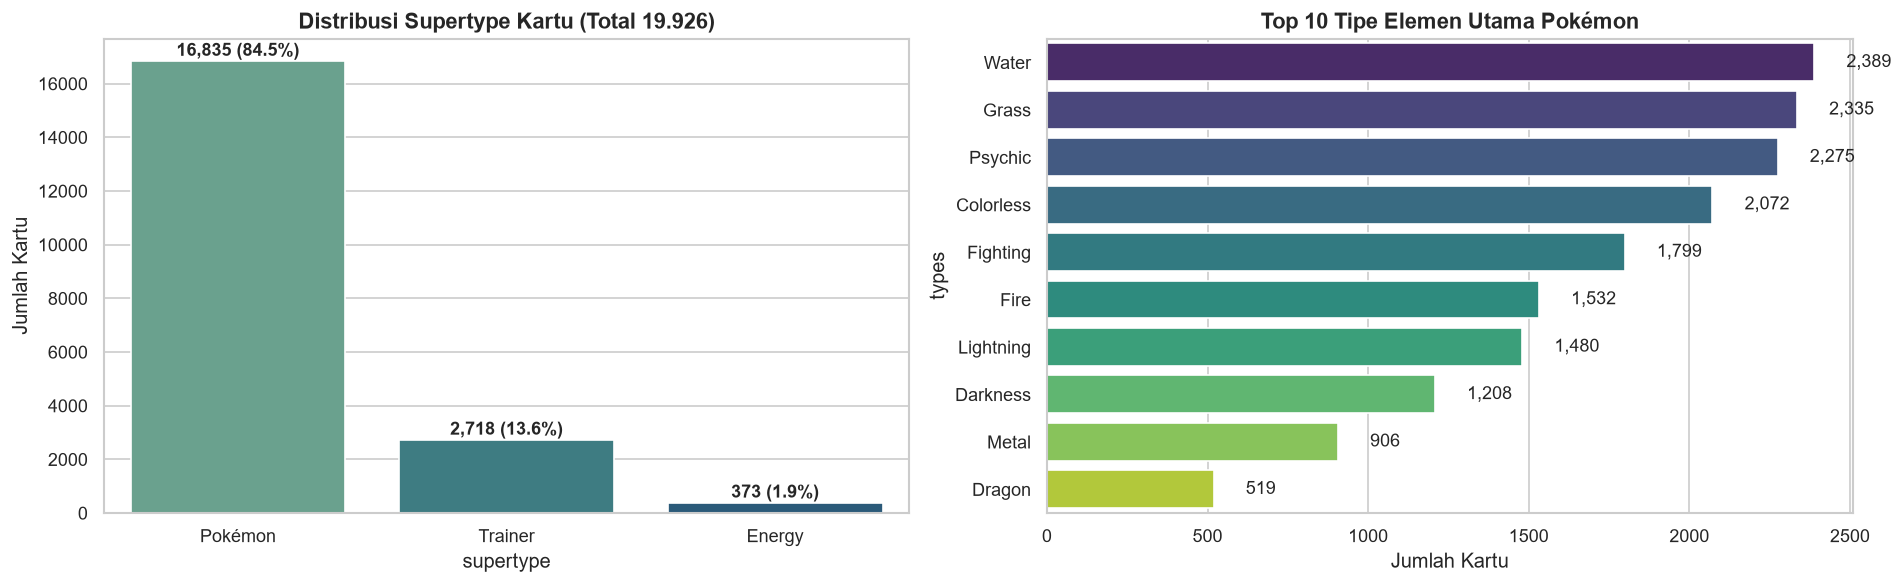

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Distribusi Supertype
supertype_counts = df['supertype'].value_counts()
sns.barplot(x=supertype_counts.index, y=supertype_counts.values, ax=axes[0], hue=supertype_counts.index, palette='crest', legend=False)
axes[0].set_title('Distribusi Supertype Kartu (Total 19.926)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Kartu')
for i, v in enumerate(supertype_counts.values):
    axes[0].text(i, v + 200, f"{v:,} ({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

# Plot 2: Distribusi Tipe Elemen (Khusus Pokémon)
pokemon_df = df[df['supertype'] == 'Pokémon'].copy()
type_counts = pokemon_df['types'].value_counts().head(10)
sns.barplot(x=type_counts.values, y=type_counts.index, ax=axes[1], hue=type_counts.index, palette='viridis', legend=False)
axes[1].set_title('Top 10 Tipe Elemen Utama Pokémon', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Kartu')
for i, v in enumerate(type_counts.values):
    axes[1].text(v + 100, i, f"{v:,}", va='center')

plt.tight_layout()
plt.show()


## 3. Analisis Kelangkaan (*Rarity*) & Faktor Edisi Vintage (Tahun Rilis)

Faktor kelangkaan (*rarity*) dan umur rilis kartu (*release_year*) merupakan variabel penentu utama multiplier harga pasar wajar ($M_{variant}$).


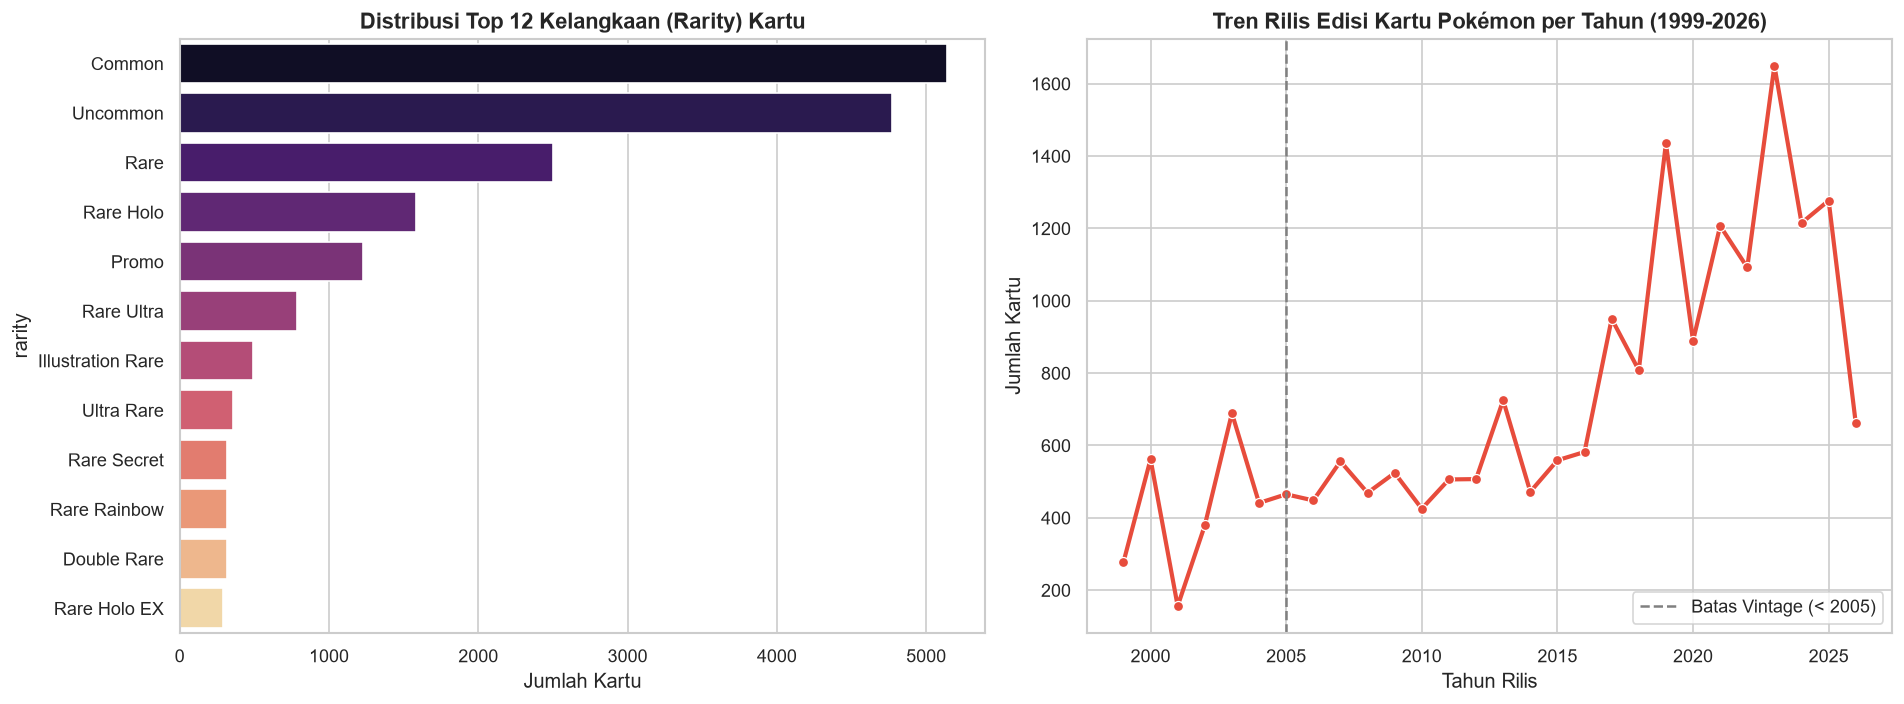

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 12 Rarity Kartu
rarity_counts = df['rarity'].value_counts().head(12)
sns.barplot(x=rarity_counts.values, y=rarity_counts.index, ax=axes[0], hue=rarity_counts.index, palette='magma', legend=False)
axes[0].set_title('Distribusi Top 12 Kelangkaan (Rarity) Kartu', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Kartu')

# Plot 2: Tren Rilis Kartu per Tahun (1999 - 2026)
year_counts = df['release_year'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, ax=axes[1], marker='o', color='#e74c3c', linewidth=2.5)
axes[1].axvline(x=2005, color='gray', linestyle='--', label='Batas Vintage (< 2005)')
axes[1].set_title('Tren Rilis Edisi Kartu Pokémon per Tahun (1999-2026)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tahun Rilis')
axes[1].set_ylabel('Jumlah Kartu')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Analisis Distribusi Harga Pasar Wajar (*Effective Market Price*)

Kolom `effective_market_price` menggabungkan data dari TCGPlayer & Cardmarket dengan **96.29% coverage** (19.186 dari 19.926 kartu memiliki data harga). Kita akan mengevaluasi distribusi harga dasar ($P_{base}$).


=== STATISTIK HARGA PASAR (EFFECTIVE MARKET PRICE IN USD) ===
count    $19,186.00
mean         $21.34
std         $108.13
min           $0.01
25%           $0.24
50%           $0.96
75%           $7.37
max       $4,500.00
Name: effective_market_price, dtype: object


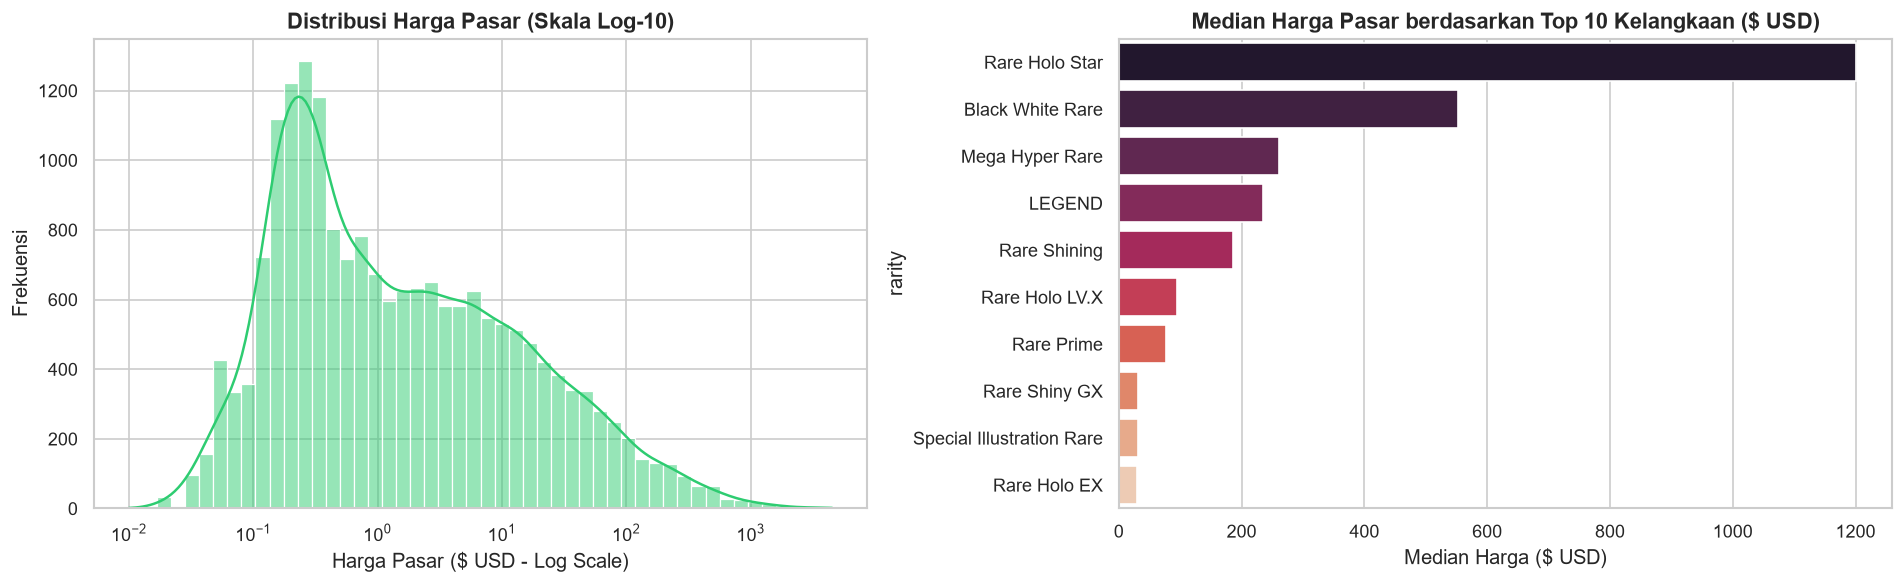

In [6]:
price_df = df.dropna(subset=['effective_market_price']).copy()

# Statistik Deskriptif Harga
print("=== STATISTIK HARGA PASAR (EFFECTIVE MARKET PRICE IN USD) ===")
print(price_df['effective_market_price'].describe().apply(lambda x: f"${x:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Log-Scale Distribution Harga (Mencegah Skewness Skala Ekstrem)
sns.histplot(price_df['effective_market_price'], bins=50, kde=True, ax=axes[0], color='#2ecc71', log_scale=True)
axes[0].set_title('Distribusi Harga Pasar (Skala Log-10)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Harga Pasar ($ USD - Log Scale)')
axes[0].set_ylabel('Frekuensi')

# Plot 2: Rata-Rata Harga per Kelangkaan (Top 10 Rarity Termahal)
top_rarity_price = price_df.groupby('rarity')['effective_market_price'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_rarity_price.values, y=top_rarity_price.index, ax=axes[1], hue=top_rarity_price.index, palette='rocket', legend=False)
axes[1].set_title('Median Harga Pasar berdasarkan Top 10 Kelangkaan ($ USD)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Harga ($ USD)')

plt.tight_layout()
plt.show()


## 5. Eksplorasi 10 Kartu Termahal di Dataset (*High-Value Outliers*)

Kartu-kartu termahal ini membuktikan keberadaan *vintage factor* (edisi lawas tahun 1999-2005) dan *rarity factor* (Secret/Holo/Promo) dalam menggerakkan harga pasar.


In [7]:
top10_expensive = df.sort_values(by='effective_market_price', ascending=False)[
    ['card_id', 'name', 'supertype', 'rarity', 'set.name', 'release_year', 'effective_market_price']
].head(10).copy()

top10_expensive['effective_market_price'] = top10_expensive['effective_market_price'].apply(lambda x: f"${x:,.2f}")
top10_expensive.rename(columns={'effective_market_price': 'market_price_usd'}, inplace=True)
top10_expensive


,card_id,name,supertype,rarity,set.name,release_year,market_price_usd
10914,ecard2-149,Lugia,Pokémon,Rare Secret,Aquapolis,2003,"$4,500.00"
10652,sm9-170,Latias & Latios-GX,Pokémon,Rare Ultra,Team Up,2019,"$4,271.62"
9105,ex15-101,Mew ★ δ,Pokémon,Rare Holo Star,Dragon Frontiers,2006,"$3,500.00"
8601,ex13-104,Pikachu ★,Pokémon,Rare Holo Star,Holon Phantoms,2006,"$3,200.00"
8755,ex7-107,Mudkip ★,Pokémon,Rare Holo Star,Team Rocket Returns,2004,"$3,101.79"
3674,np-28,Championship Arena,Trainer,Promo,Nintendo Black Star Promos,2003,"$2,999.00"
18991,bp-8,Rocket's Mewtwo,Pokémon,Promo,Best of Game,2002,"$2,400.00"
18875,swsh7-215,Umbreon VMAX,Pokémon,Rare Rainbow,Evolving Skies,2021,"$2,298.34"
8807,ex7-108,Torchic ★,Pokémon,Rare Holo Star,Team Rocket Returns,2004,"$1,969.69"
2012,pop5-16,Espeon ★,Pokémon,Rare,POP Series 5,2007,"$1,900.00"


## 6. Kesimpulan Audit & Implikasi Pada Engine AI

1. **Kelayakan Model Computer Vision 1 (FAISS):**  
   Missing values pada metadata (`types`, `hp`, `rarity`) **0% berdampak** pada Model 1. FAISS bekerja murni pada piksel gambar `compressed_images/*.jpg` yang 100% utuh & sinkron 1-to-1 (19.926 kartu).
2. **Kelayakan Valuation Engine ($P_{final}$):**  
   - 96.29% kartu memiliki harga aktif. Untuk 740 kartu tanpa harga (3.71%), backend akan menggunakan *fallback strategy* berbasis *median price* per `rarity` & `release_year`.
   - Variabel `release_year` (< 2005) & `rarity` terbukti menjadi driver harga paling signifikan untuk dikalkulasikan pada $M_{variant}$.
